# U23AI035 - LAB 3 - RAI

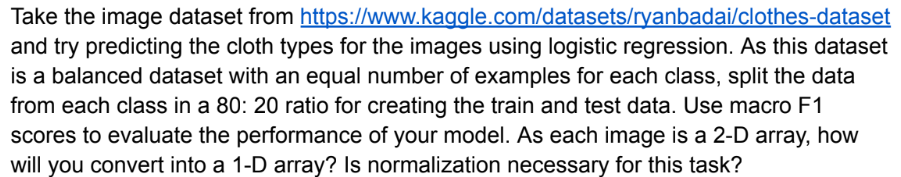

In [25]:
import os
import cv2
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
DATASET_PATH = 'Clothes_Dataset'
IMG_SIZE = (32, 32)

In [27]:
X, y = [], []

In [28]:
classes = sorted(os.listdir(DATASET_PATH))

In [29]:
for label, cls in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)

        img = img.flatten()
        X.append(img)
        y.append(label)

In [30]:
X = np.array(X)
y = np.array(y)

In [31]:
X = X / 255.0

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [33]:
model = LogisticRegression(max_iter=2000, C=0.1)

In [34]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [35]:
y_pred = model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
print("Macro F1-score:", macro_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

Macro F1-score: 0.3003135996840118

Classification Report:
                precision    recall  f1-score   support

        Blazer       0.18      0.15      0.16       100
Celana_Panjang       0.34      0.27      0.30       100
 Celana_Pendek       0.32      0.43      0.37       100
          Gaun       0.31      0.33      0.32       100
        Hoodie       0.31      0.23      0.26       100
         Jaket       0.41      0.43      0.42       100
   Jaket_Denim       0.32      0.27      0.29       100
Jaket_Olahraga       0.23      0.21      0.22       100
         Jeans       0.57      0.51      0.54       100
          Kaos       0.25      0.35      0.29       100
        Kemeja       0.29      0.31      0.30       100
        Mantel       0.27      0.22      0.24       100
          Polo       0.20      0.22      0.21       100
           Rok       0.30      0.21      0.25       100
        Sweter       0.29      0.40      0.34       100

      accuracy                           0.

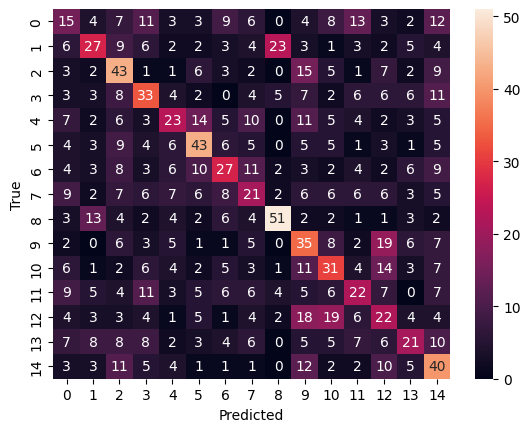

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

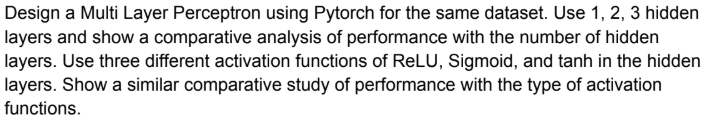

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [38]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [39]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=64,
    shuffle=False
)

In [40]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes, activation):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(activation)
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [41]:
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

In [42]:
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())

    return f1_score(y_true, y_pred, average='macro')

In [43]:
input_dim = X_train.shape[1]
num_classes = len(torch.unique(y_train))

activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh()
}

hidden_layer_configs = {
    "1 Hidden": [256],
    "2 Hidden": [256, 128],
    "3 Hidden": [256, 128, 64]
}

results = {}

In [46]:
for act_name, act_fn in activations.items():
    for layer_name, hidden_layers in hidden_layer_configs.items():

        model = MLP(
            input_dim=input_dim,
            hidden_layers=hidden_layers,
            num_classes=num_classes,
            activation=act_fn
        )

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        train_model(model, train_loader, criterion, optimizer)
        f1 = evaluate_model(model, test_loader)

        results[(layer_name, act_name)] = f1
        print(layer_name, act_name, "Macro F1:", f1)

1 Hidden ReLU Macro F1: 0.33052290725289096
2 Hidden ReLU Macro F1: 0.3452489488107903
3 Hidden ReLU Macro F1: 0.3263525747058211
1 Hidden Sigmoid Macro F1: 0.3133972263432313
2 Hidden Sigmoid Macro F1: 0.3123674035245399
3 Hidden Sigmoid Macro F1: 0.26406796218882994
1 Hidden Tanh Macro F1: 0.311187503557288
2 Hidden Tanh Macro F1: 0.3426199697206002
3 Hidden Tanh Macro F1: 0.3211572412114305


### Macro F1-Scores
| Hidden Layers | ReLU | Tanh | Sigmoid |
|---------------|------|------|---------|
| 1 Hidden | 0.33 | 0.31 | 0.31 | 
| 2 Hidden | 0.34 | 0.34 | 0.31 |
| 3 Hidden | 0.32 | 0.32 | 0.26 |